This notebook loads the saved Rashomon experiment results and performs **basic sanity checks**.

**Purpose**
- Verify shapes and consistency of saved artifacts
- Inspect prediction variance and instability
- Ensure Rashomon composition looks sensible

## 1. Imports and paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Adjust this path to the run you want to inspect
# Path is relative to notebook location (notebooks/ directory)
BASE_PATH = Path("../results/compas/seed=42_eps=0.01")
assert BASE_PATH.exists(), f"Result directory not found: {BASE_PATH.absolute()}"

## 2. Load saved artifacts

In [2]:
P = np.load(BASE_PATH / "P_test.npy")
metrics = np.load(BASE_PATH / "metrics.npz")
meta = pd.read_csv(BASE_PATH / "meta.csv")
X_test = pd.read_csv(BASE_PATH / "X_test.csv")
y_test = np.load(BASE_PATH / "y_test.npy")

## 3. Shape and consistency checks

In [3]:
print("P shape (n_models, n_obs):", P.shape)
print("X_test shape:", X_test.shape)
print("meta shape:", meta.shape)
print("y_test shape:", y_test.shape)

P shape (n_models, n_obs): (24, 1443)
X_test shape: (1443, 5)
meta shape: (24, 4)
y_test shape: (1443,)


In [4]:
assert P.shape[1] == X_test.shape[0] == len(y_test)
assert P.shape[0] == len(meta)

## 4. Inspect Rashomon composition

In [5]:
meta['model_name'].value_counts()

model_name
MLP    14
GBM     9
RF      1
Name: count, dtype: int64

In [6]:
meta['val_loss'].describe()

count    24.000000
mean      0.601018
std       0.002740
min       0.594976
25%       0.599655
50%       0.601671
75%       0.603246
max       0.604714
Name: val_loss, dtype: float64

## 5. Prediction variance diagnostics

In [7]:
v = metrics['variance']

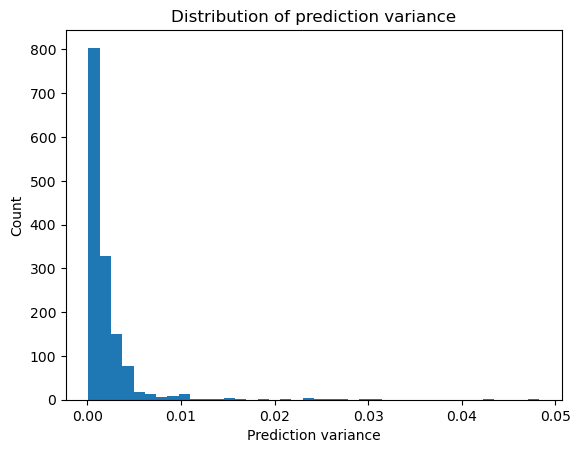

In [8]:
plt.hist(v, bins=40)
plt.xlabel("Prediction variance")
plt.ylabel("Count")
plt.title("Distribution of prediction variance")
plt.show()

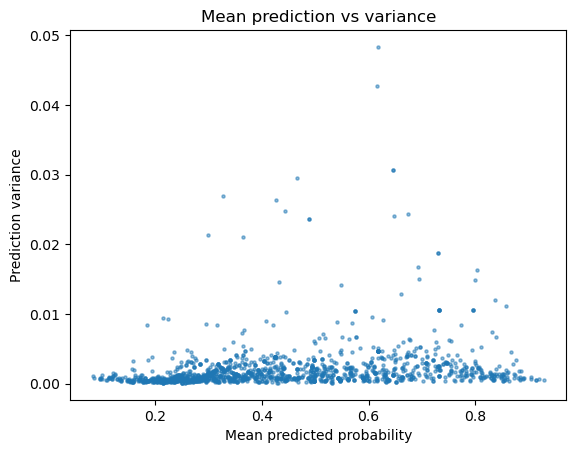

In [9]:
mean_p = P.mean(axis=0)
plt.scatter(mean_p, v, s=5, alpha=0.5)
plt.xlabel("Mean predicted probability")
plt.ylabel("Prediction variance")
plt.title("Mean prediction vs variance")
plt.show()

## 6. Flip instability (decision-relevant)

In [10]:
flip = metrics['flip_instability']

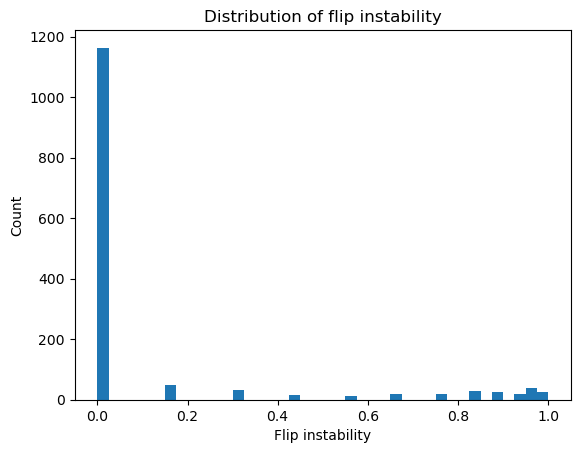

In [11]:
plt.hist(flip, bins=40)
plt.xlabel("Flip instability")
plt.ylabel("Count")
plt.title("Distribution of flip instability")
plt.show()

In [12]:
print("Fraction of points with high flip instability (>0.9):",
      (flip > 0.9).mean())

Fraction of points with high flip instability (>0.9): 0.056133056133056136


## 7. Basic edge-case checks

In [13]:
print("Points with ~zero variance:", (v < 1e-6).sum())
print("Points with max variance:", (v > np.percentile(v, 99)).sum())

Points with ~zero variance: 0
Points with max variance: 14


In [14]:
# Sanity: variance should be zero if only one Rashomon model
if P.shape[0] == 1:
    assert np.allclose(v, 0)